# Notebook - Find best Drug compound for Staphylococcus aureus bacteria

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [114]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [115]:
import os
import csv
import numpy as np
import pandas as pd


from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [116]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [117]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [118]:
allBacteriaData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM_wMACAW.csv')

In [119]:
allBacteriaData_chEMBL_wMACAW

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,-0.030681,-0.127148,-0.133923,-0.111388,0.084428,0.026623,0.160258,0.116619,-0.014980,0.063359
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,-0.092330,0.011442,-0.113492,0.153756,0.124025,-0.051814,0.022991,0.030415,-0.106818,0.018152
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,-0.127232,-0.126869,-0.091832,0.029565,0.068529,-0.010103,0.059577,0.082352,-0.124721,0.093080
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.123449,-0.019707,0.055608,0.003291,0.046833,0.041516,-0.002765,-0.004522,-0.037508,0.021961
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.039788,-0.006643,0.058043,0.085609,-0.011400,-0.017518,0.076169,0.022291,-0.003597,-0.032543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162373,309581,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,C83H132N34O19,YJJSQMDJLSCZBG-OWVMLFFHSA-N,InChI=1S/C83H132N34O19/c1-42(2)29-57(75(132)10...,1910.19,Unknown,33500.00,nM,...,0.067898,0.020046,0.044115,-0.109868,-0.055894,0.110857,-0.255286,0.044038,-0.069828,-0.119326
162374,309582,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,C83H132N34O19,YJJSQMDJLSCZBG-OWVMLFFHSA-N,InChI=1S/C83H132N34O19/c1-42(2)29-57(75(132)10...,1910.19,Unknown,67010.00,nM,...,0.067898,0.020046,0.044115,-0.109868,-0.055894,0.110857,-0.255286,0.044038,-0.069828,-0.119326
162375,309595,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,C53H84O23,YEMXBZDJQOAHLA-KJIQPPNDSA-N,InChI=1S/C53H84O23/c1-48(2)29-9-12-52(6)30(8-7...,1089.23,Unknown,1148900.00,nM,...,0.034797,-0.073582,-0.181693,0.065255,0.069087,-0.058363,-0.012869,-0.083648,-0.090124,-0.091547
162376,309598,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,C19H21ClN4O,REXIYIBKBWXIKH-UHFFFAOYSA-N,InChI=1S/C19H21ClN4O/c20-14-5-6-17-15(13-14)19...,356.86,NaN,1510.00,nM,...,0.002278,0.035289,-0.055769,0.067635,-0.011393,-0.080972,0.108266,0.025874,0.174277,0.035933


### Filter columns

In [120]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenesData_chEMBL_combined.csv
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenesData_chEMBL_combined.csv
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenesData_chEMBL_combined.csv
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenesData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [121]:
allBacteriaData_chEMBL_wMACAW['Virus'] = allBacteriaData_chEMBL_wMACAW['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL_wMACAW.rename(columns={'Virus': 'Bacteria'}, inplace=True)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenes
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenes
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenes
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenes


### Keep only data for `Staphylococcus_aureus` bacteria

In [122]:
StaphylococcusBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW[allBacteriaData_chEMBL_wMACAW['Bacteria'] == 'Staphylococcus_aureus']
StaphylococcusBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
18773,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus
...,...,...,...,...,...
142570,CHEMBL5574512,CC(C)C[C@H](N)CN(CC(=O)N[C@@H](CCCCN)C(=O)N[C@...,1.000000e+02,4.000,Staphylococcus_aureus
142571,CHEMBL5570559,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCC...,1.000000e-26,32.000,Staphylococcus_aureus
142572,CHEMBL5570291,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCC...,1.000000e-26,32.000,Staphylococcus_aureus
142573,CHEMBL5574512,CC(C)C[C@H](N)CN(CC(=O)N[C@@H](CCCCN)C(=O)N[C@...,1.000000e-26,32.000,Staphylococcus_aureus


### Rename columns

In [123]:
StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Bacteria" : "BacteriaClassifier",
})
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
18773,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus


### Compound Distribution Across Bacteriaes

In [124]:
Bacteria_counts = StaphylococcusBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(StaphylococcusBacteriaData_chEMBL_wMACAW)

print(f"\n{'Bacteria':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for Bacteria, count in Bacteria_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{Bacteria:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique Bacteriaes: {len(Bacteria_counts)}")


Bacteria                            Count   Percentage
----------------------------------------------------------------------
Staphylococcus_aureus              123802      100.00%
----------------------------------------------------------------------
TOTAL                              123802      100.00%

Number of unique Bacteriaes: 1


### Add `ID` column to left

In [125]:
StaphylococcusBacteriaData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(StaphylococcusBacteriaData_chEMBL_wMACAW) + 1))
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
18773,1,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,2,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,3,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,4,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,5,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [126]:
StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
18773,1,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,0.780,Staphylococcus_aureus
18774,2,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,25.000,Staphylococcus_aureus
18775,3,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,0.016,Staphylococcus_aureus
18776,4,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,0.125,Staphylococcus_aureus
18777,5,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,0.250,Staphylococcus_aureus


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [127]:
print("Original shape:", StaphylococcusBacteriaData_chEMBL_wMACAW.shape)

StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW[StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'].notna() 
    & (StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'] > 0) & (StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", StaphylococcusBacteriaData_chEMBL_wMACAW.shape)

Original shape: (123802, 5)
Shape after cleaning 'pPotency' value: (90807, 5)


### Remove duplicate compounds using Compute median potency per (Smiles, Bacteria) pair

In [128]:
duplicates = StaphylococcusBacteriaData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'BacteriaClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 57014


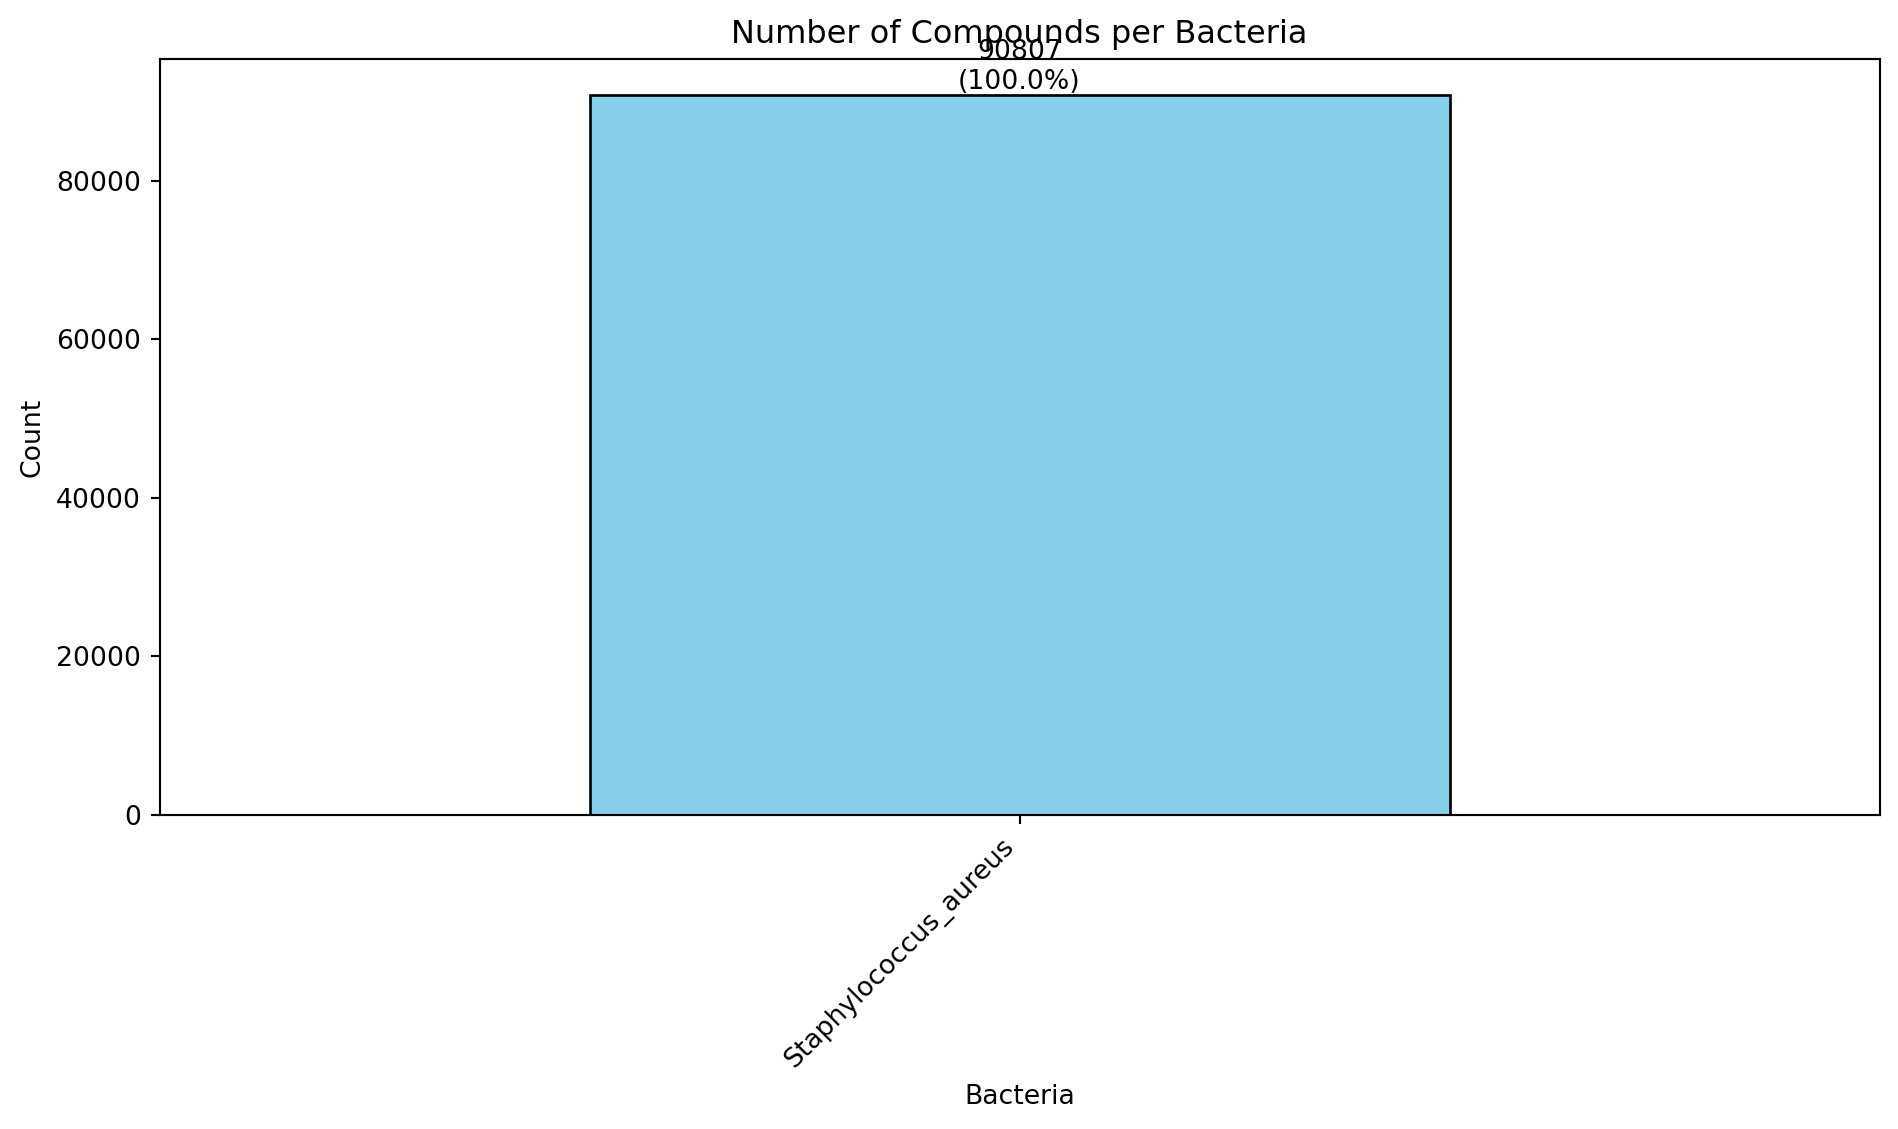

In [129]:
# Get counts and percentages
counts = StaphylococcusBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [130]:
StaphylococcusBacteriaData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "StaphylococcusBacteriaData_chEMBL_wMACAW_MLready.csv"), index=False)

### pPotency value distribution across each bacteria

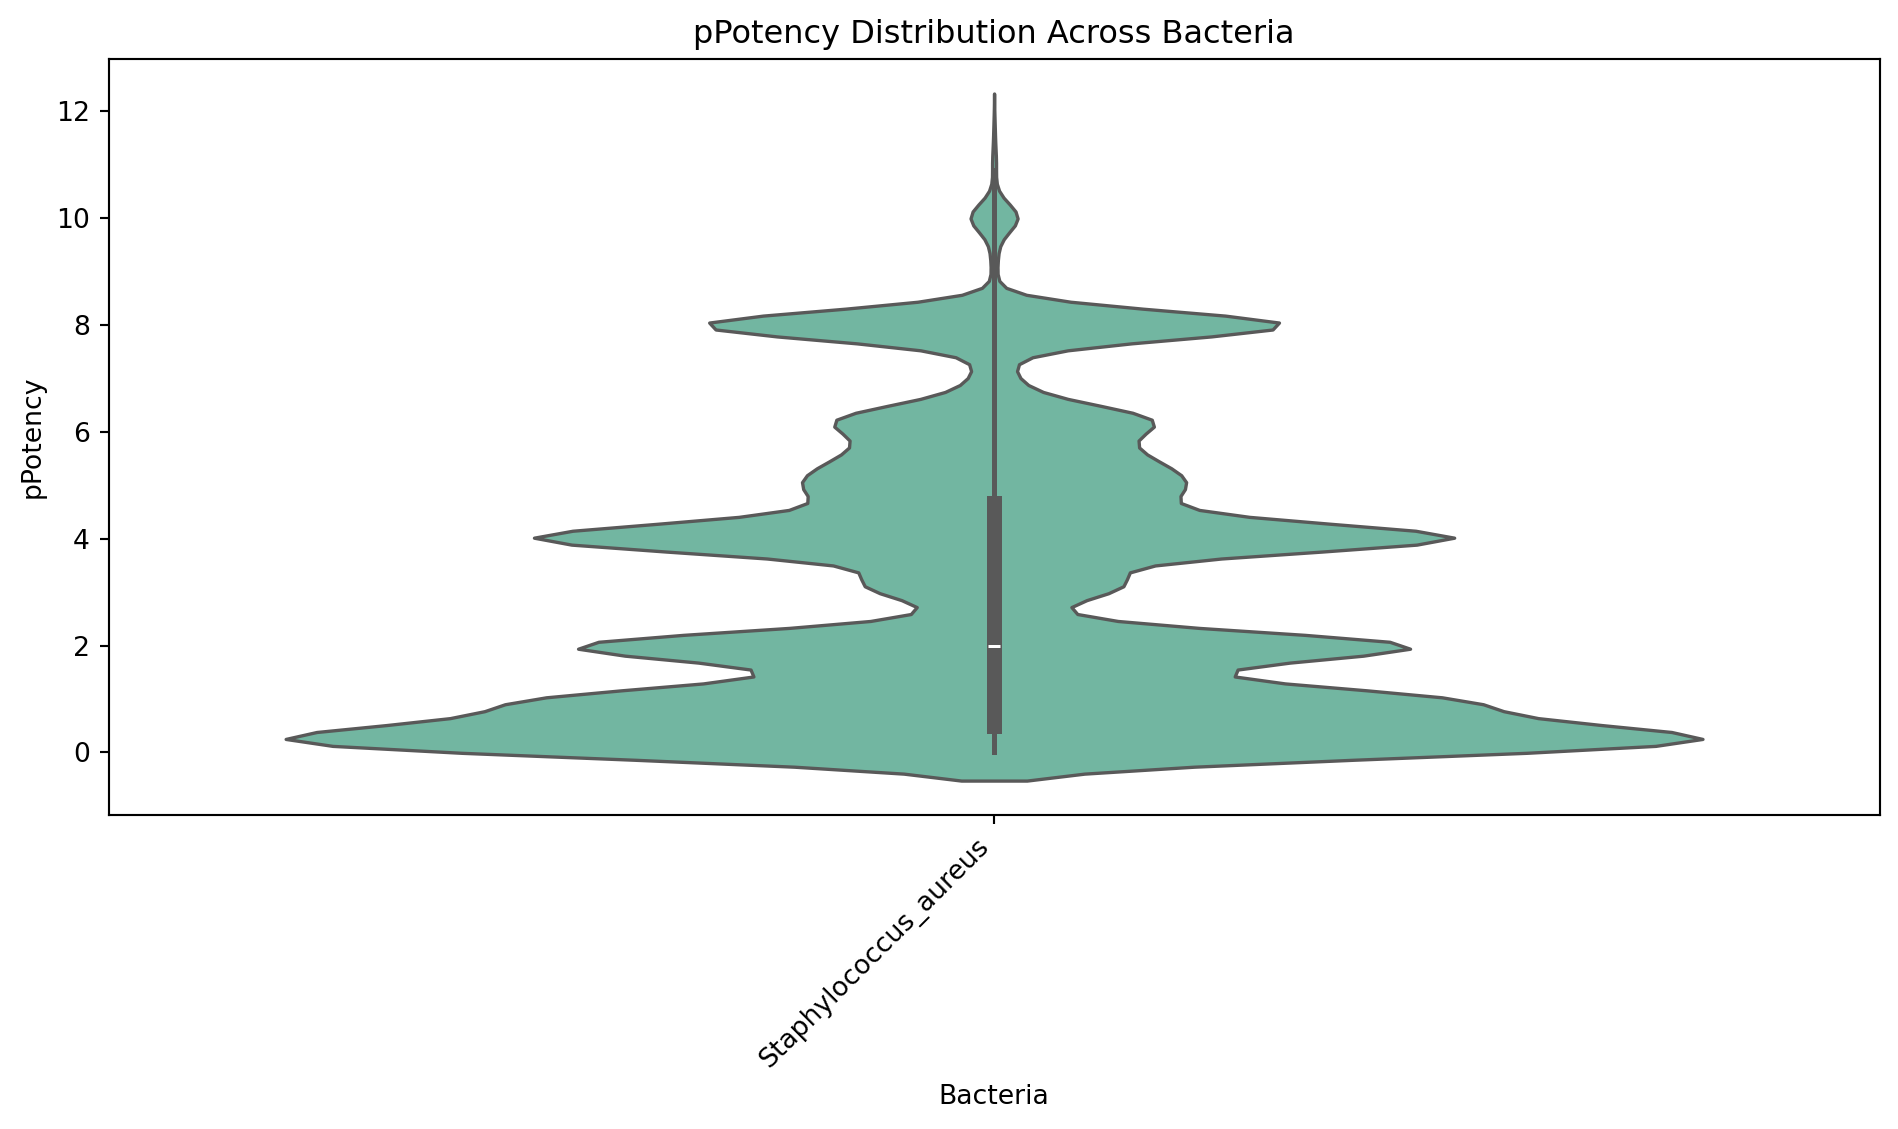

In [131]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=StaphylococcusBacteriaData_chEMBL_wMACAW,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

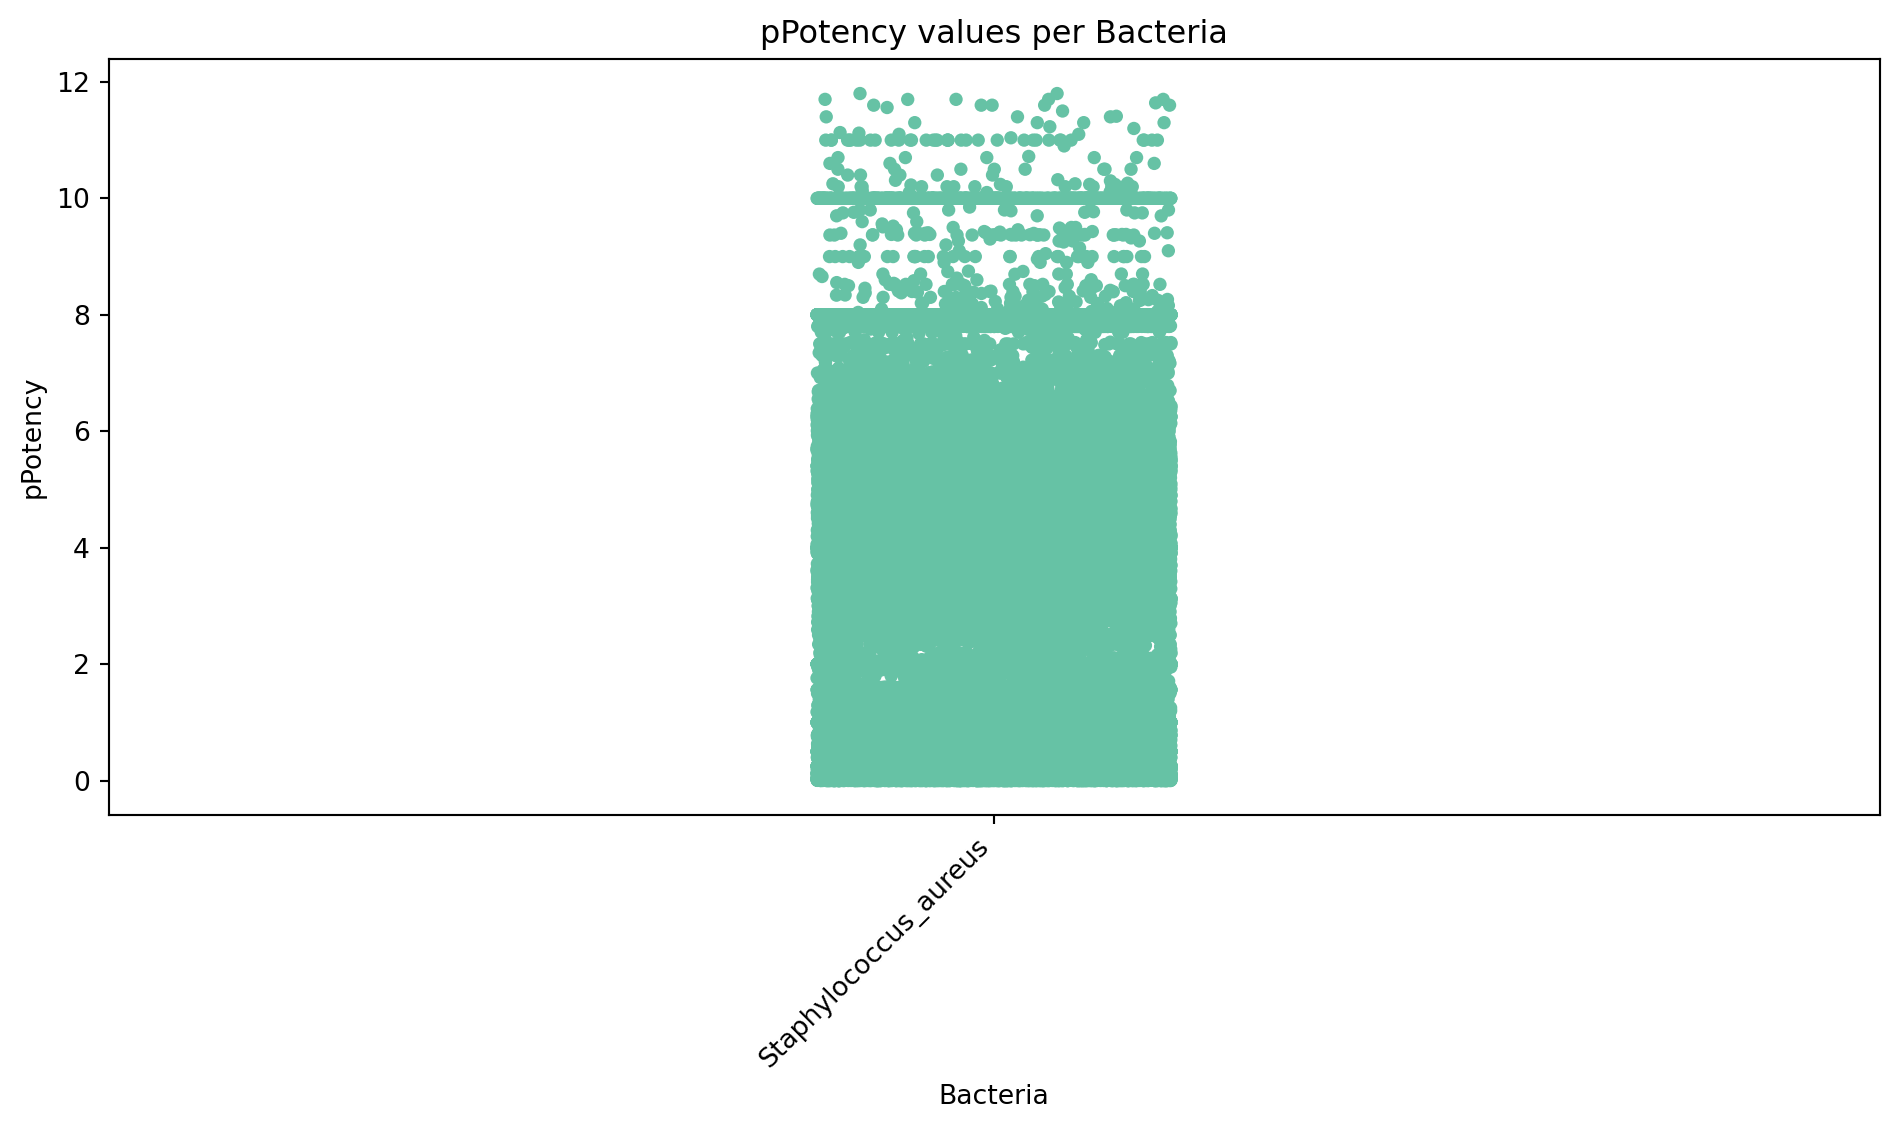

In [132]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=StaphylococcusBacteriaData_chEMBL_wMACAW,
    x='BacteriaClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [133]:
# df = StaphylococcusBacteriaData_chEMBL_wMACAW
Y = StaphylococcusBacteriaData_chEMBL_wMACAW.pPotency
smiles = StaphylococcusBacteriaData_chEMBL_wMACAW.Smiles

In [134]:
print(len(smiles))

90807


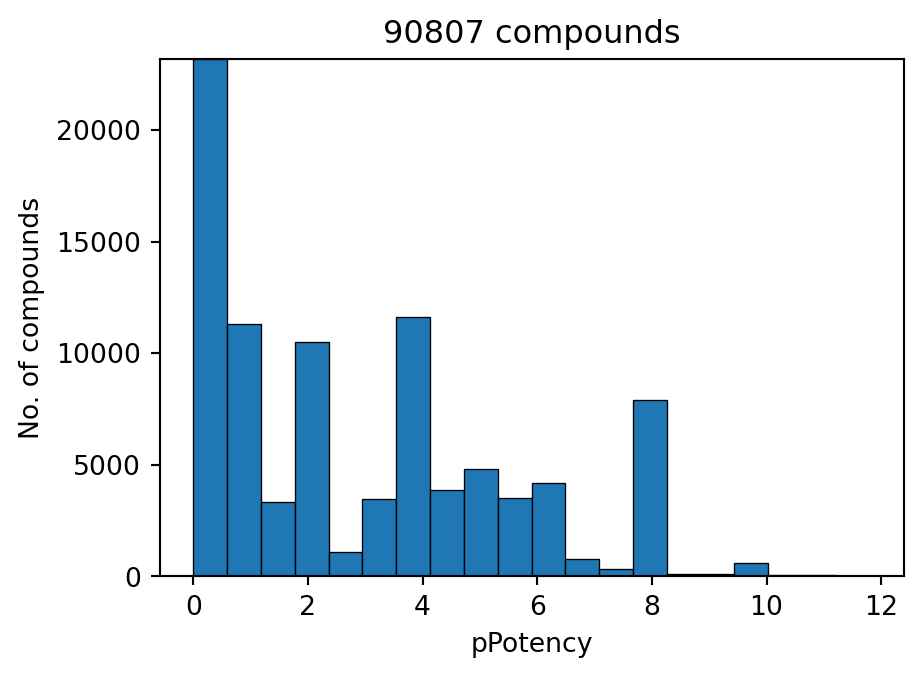

In [135]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [136]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [137]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [138]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [139]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 90807 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [140]:
save_path = resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

Partition 5/10
  Fold 5 - Train MAE: 1.69, Test MAE: 1.87
Partition 9/10
  Fold 9 - Train MAE: 1.66, Test MAE: 2.00
Partition 4/10
  Fold 4 - Train MAE: 1.81, Test MAE: 2.13
Partition 8/10
  Fold 8 - Train MAE: 1.85, Test MAE: 1.80
Partition 10/10
  Fold 10 - Train MAE: 1.64, Test MAE: 1.75
Partition 2/10
  Fold 2 - Train MAE: 1.67, Test MAE: 1.85
Partition 1/10
  Fold 1 - Train MAE: 1.69, Test MAE: 1.88
Partition 6/10
  Fold 6 - Train MAE: 1.69, Test MAE: 2.00
Partition 7/10
  Fold 7 - Train MAE: 1.63, Test MAE: 2.02
Partition 3/10
  Fold 3 - Train MAE: 1.65, Test MAE: 2.14


### ML predictions with Test only results

### ML predictions with Train + Test results

In [101]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

# ===== DEFINE FUNCTION FOR SINGLE FOLD =====
def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Clone MACAW to avoid conflicts in parallel execution
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=1)  # n_jobs=1 to avoid nested parallelism
    grid.fit(X_train, y_train)
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all results
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': grid.best_params_
    }


# ===== RUN PARALLEL CROSS-VALIDATION =====
print("Starting parallel cross-validation with parallel cores...\n")

results = Parallel(n_jobs=8, verbose=50)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)


# ===== COMBINE RESULTS =====
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)


# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params per fold (sample): {best_params_per_fold[:3]}")

Starting parallel cross-validation with parallel cores...

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   12.7s
[Parallel(n_jobs=8)]: Done   2 out of  10 | elapsed:   12.9s remaining:   51.7s
[Parallel(n_jobs=8)]: Done   3 out of  10 | elapsed:   13.1s remaining:   30.6s
[Parallel(n_jobs=8)]: Done   4 out of  10 | elapsed:   13.8s remaining:   20.7s
[Parallel(n_jobs=8)]: Done   5 out of  10 | elapsed:   14.0s remaining:   14.0s
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:   14.0s remaining:    9.3s
[Parallel(n_jobs=8)]: Done   7 out of  10 | elapsed:   14.2s remaining:    6.1s
[Parallel(n_jobs=8)]: Done   8 out of  10 | elapsed:   14.3s remaining:    3.6s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:   20.3s finished

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  1.70
  RMSE: 2.21
  R²:   0.26
Test Set:
  MAE: 

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.png


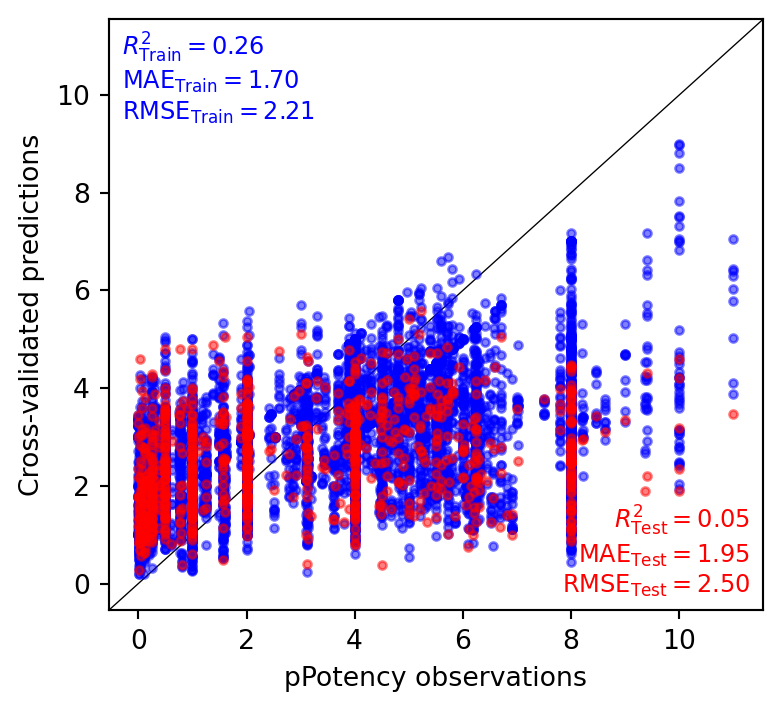

In [103]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [104]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [105]:
X_all = mcw.transform(smiles)
X_all.shape

(1000, 15)

Training samples: 800
Test samples: 200
Feature dimensions: 15

Running GridSearchCV with 8 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 1
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 1.92

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.13            -0.02           0.15           
MAE        1.73            1.92            0.19           
RMSE       2.40            2.56            0.15           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_fullData_TrTs.svg
Saved: /mnt/data.es

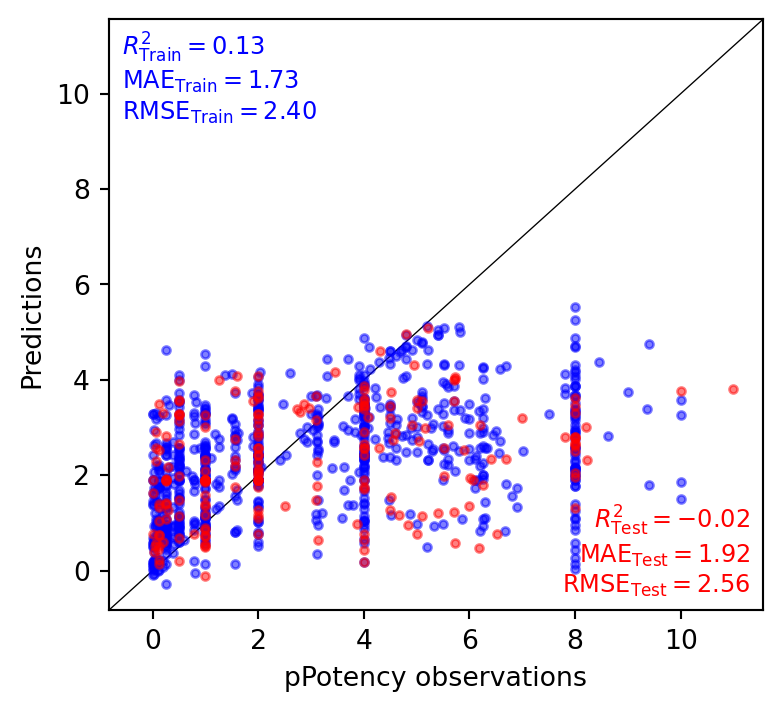

CPU times: user 1.52 s, sys: 53.7 ms, total: 1.57 s
Wall time: 3.91 s


In [106]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 8

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2. Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [107]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [108]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [109]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

Let us represent the predictions of both models:

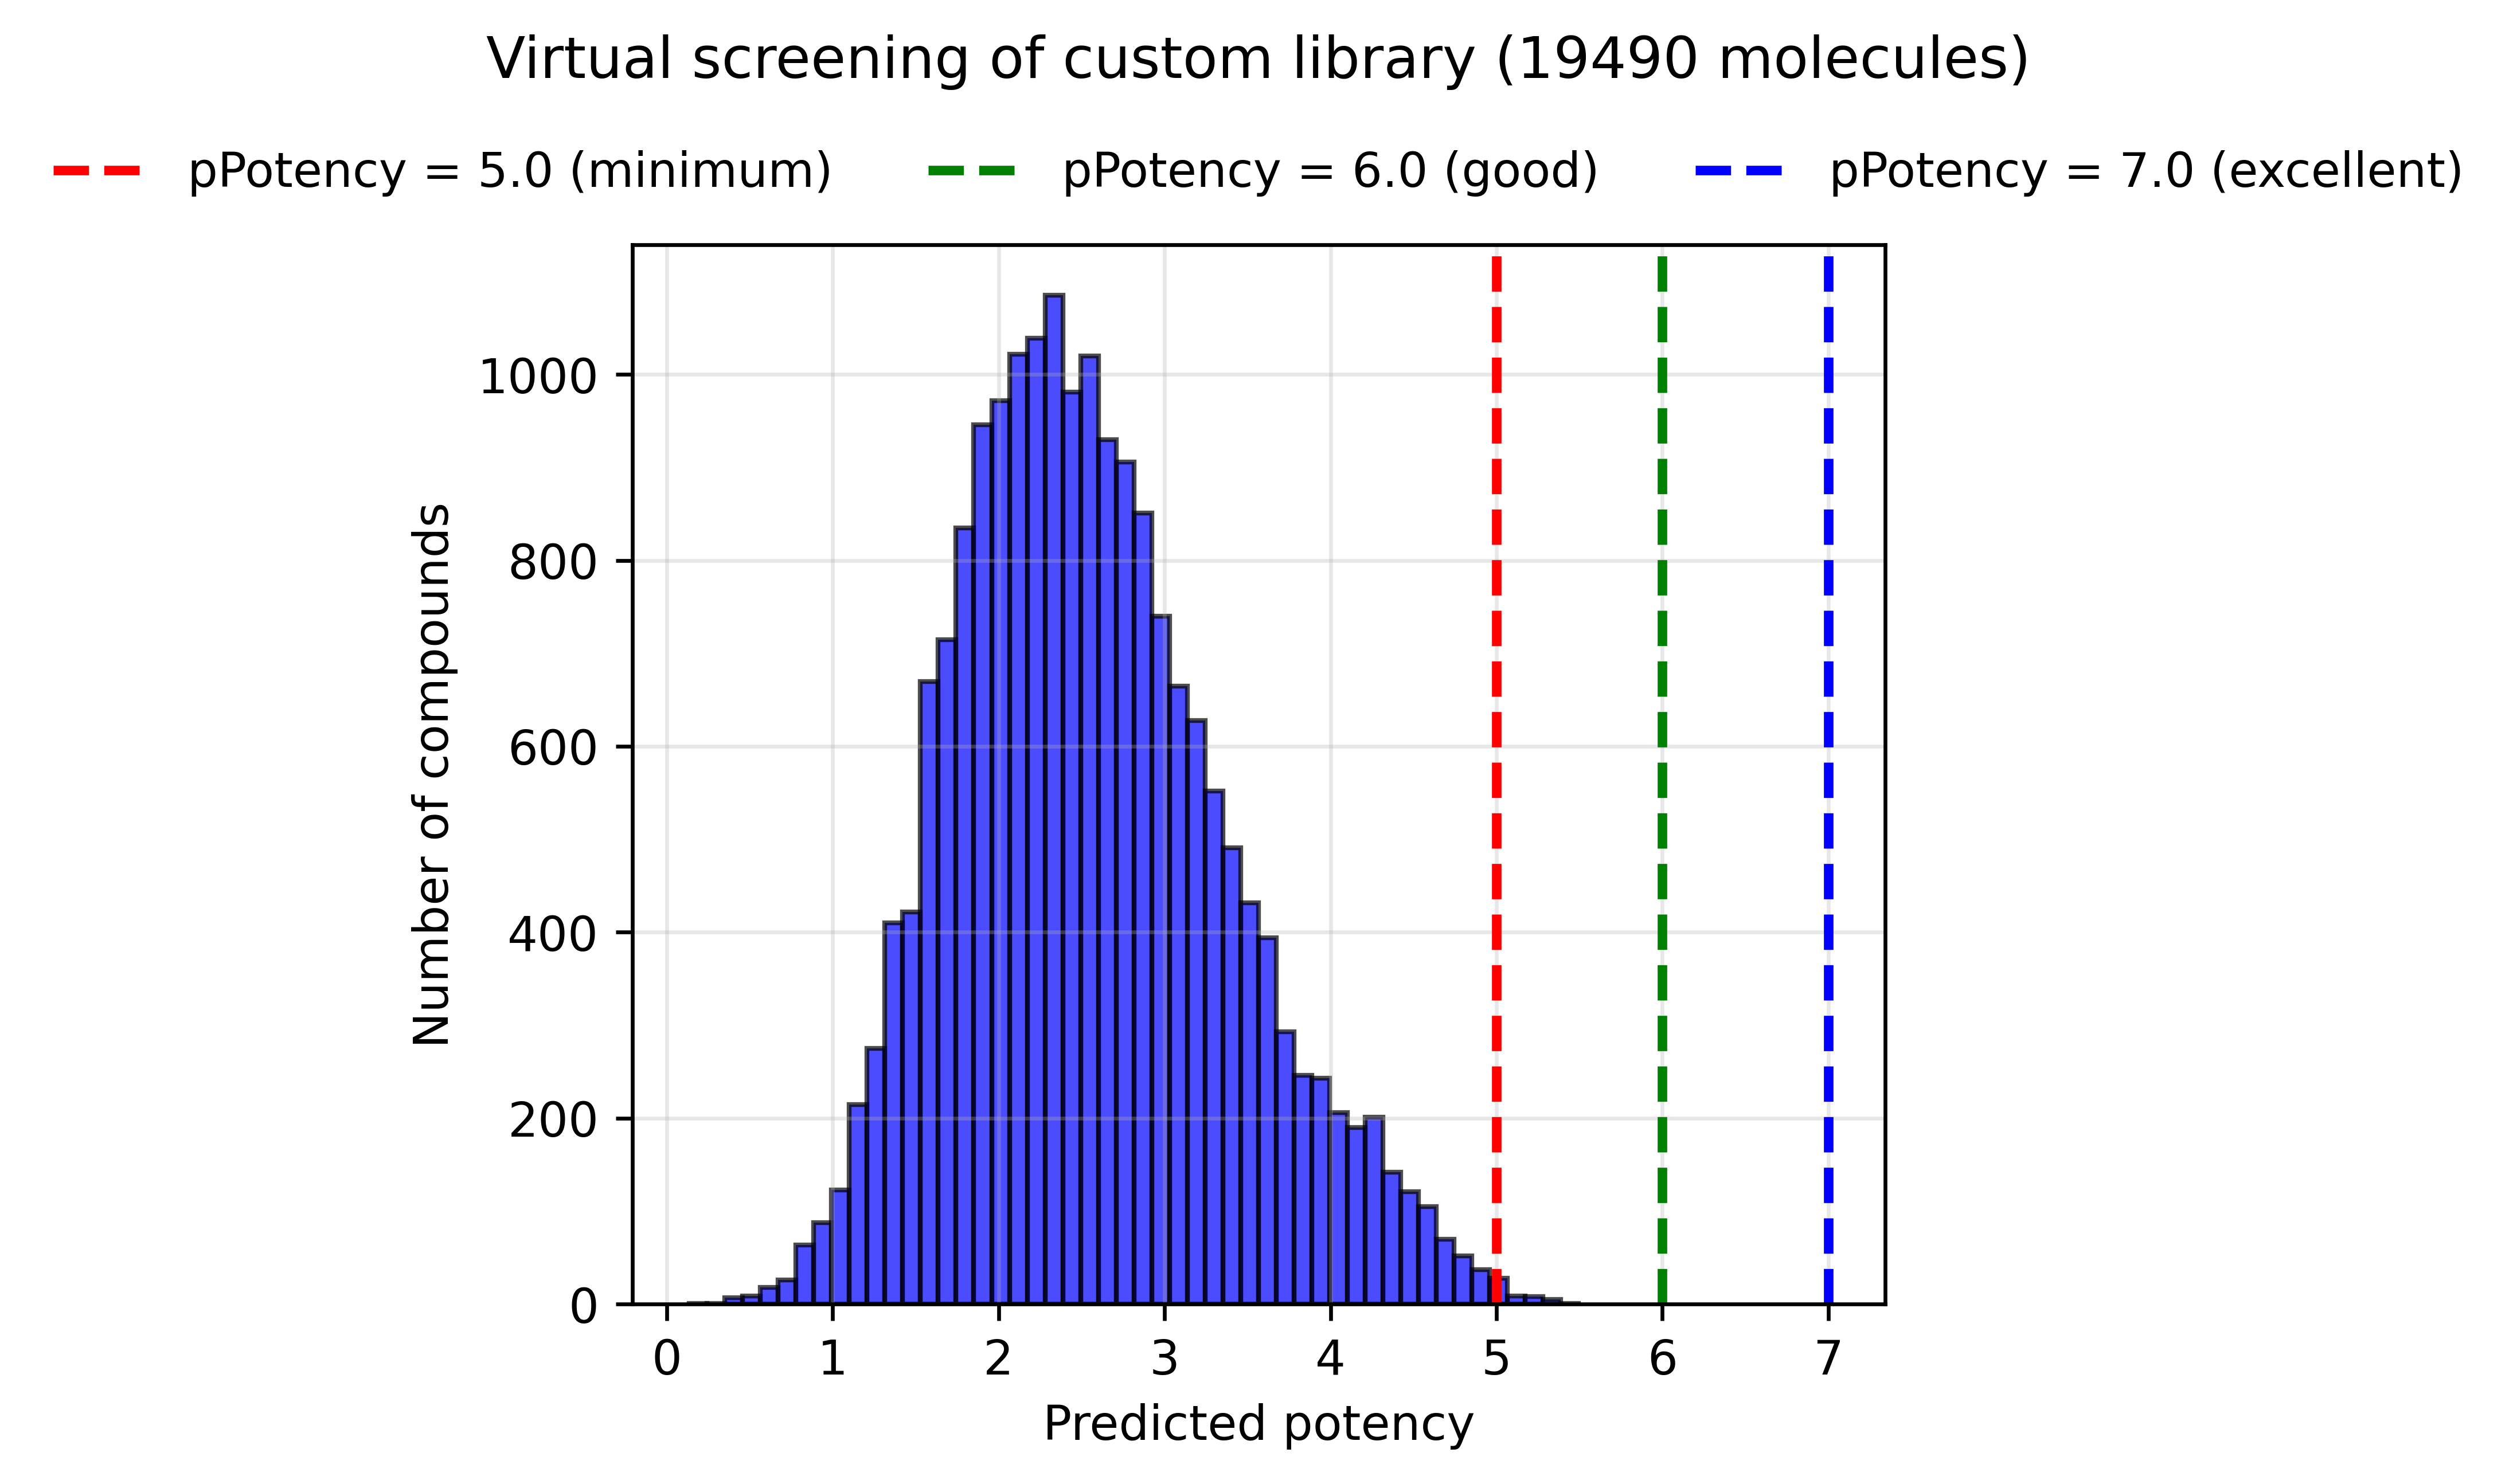

In [110]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [111]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 34 compounds


In [112]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction


In [113]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

ExpatError: not well-formed (invalid token): line 1, column 1